# 06 — Linear Models: Ridge, Lasso, ElasticNet

**Notebook 6 of 8 — Regularised linear regression as a sanity check**

---

## 6.1  Why linear models still matter

Tree models can fit anything, which makes them excellent predictors but
**poor diagnostic tools**. Linear models give us three things trees do not:

1. **Coefficient signs.** A coefficient is positive or negative — the
   sign tells us whether more of feature $x_j$ pushes the prediction up
   or down. Trees can learn the same relationship locally but you cannot
   summarise it with a single sign.
2. **Quantitative units.** A coefficient says "one extra unit of
   `lag_12_clean` raises the forecast by $\beta_j$ ships per month".
   No black-box explanation needed.
3. **A *theoretical* lower bound on accuracy.** If a regularised linear
   model already gets within a few percent of LightGBM, the gain from
   non-linearity is small and the simpler model should be preferred for
   production. If LightGBM is dramatically better, the gap is the value
   of feature interactions.

We test **three regularisers**:

| Model         | Penalty | Property |
|---------------|---------|----------|
| **Ridge**     | $\lambda\,\\|\beta\\|_2^2$ | Shrinks correlated features together; never sets coefficients to zero |
| **Lasso**     | $\lambda\,\\|\beta\\|_1$  | Sparsity — forces small coefficients to exactly zero |
| **ElasticNet**| $\alpha\,\lambda\\|\beta\\|_1 + (1-\alpha)\,\lambda\\|\beta\\|_2^2$ | Compromise — sparse + grouped |

All three minimise:

$$
\min_{\beta}\;\frac{1}{2n}\,\sum_{i=1}^{n}\bigl(y_i - x_i^{\top}\beta\bigr)^2
\;+\; \mathcal{P}(\beta)
$$

where $\mathcal{P}$ is the penalty above. Cross-validation chooses
$\lambda$ inside each fit.

## 6.2  Pre-processing

Linear models are scale-sensitive — a feature with a large range will
dominate. We:

1. **Standardise** with `StandardScaler` (zero mean, unit variance).
2. **Drop COVID rows** from training (the linear loss has no clean
   sample-weighting equivalent that LightGBM's API offers).
3. **Use the same correlation-pruned feature list** as the trees.


In [1]:
# ── Setup ─────────────────────────────────────────────────────────
import warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import wz_ml_utils as U

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 110})

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
MAX_PORTS = 78

LIN_MODELS = {
    "ridge":      lambda: RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]),
    "lasso":      lambda: LassoCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0],
                                  max_iter=20000),
    "elasticnet": lambda: ElasticNetCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0],
                                       l1_ratio=[0.2, 0.5, 0.8],
                                       max_iter=20000),
}


In [2]:
df_panel = U.load_features()
print(f"Panel shape : {df_panel.shape}")


Panel shape : (12692, 54)


## 6.3  Generic fit-predict factory

In [3]:
def make_lin_fit_predict(model_factory):
    def lin_fit_predict(df_train, df_test, features):
        df_tr = df_train[~df_train["year"].isin(U.COVID_YEARS)].copy()
        if len(df_tr) < 24:
            df_tr = df_train.copy()
        Xtr = df_tr[features].fillna(0).astype(float).values
        ytr = df_tr[U.TARGET].astype(float).values
        Xte = df_test[features].fillna(0).astype(float).values

        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("model", model_factory()),
        ])
        pipe.fit(Xtr, ytr)
        return np.maximum(1.0, pipe.predict(Xte))
    return lin_fit_predict


## 6.4  Walk-forward CV for all three regularisers

In [4]:
all_metrics = {}
for name, factory in LIN_MODELS.items():
    t0 = time.time()
    m = U.evaluate_model_across_ports(
        df_panel, make_lin_fit_predict(factory),
        model_name=name,
        max_ports=MAX_PORTS,
    )
    print(f"{name:>10} : {len(m):>4} fold scores  ({time.time()-t0:.1f}s)")
    U.save_metrics(name, m)
    all_metrics[name] = m


     ridge :  226 fold scores  (2.3s)


     lasso :  226 fold scores  (3.9s)


elasticnet :  226 fold scores  (8.4s)


In [5]:
# Combined per-fold summary
combined = pd.concat(all_metrics.values(), ignore_index=True)
summary = U.summarise(combined, df_panel)
summary.sort_values(["fold_year","wmape"])


,model,fold_year,n_ports,wmae,wrmse,wmape,wr2
4,lasso,2019,34,1339.542100,2416.012983,7.593016,0.352316
8,ridge,2019,34,1460.403867,2506.513407,7.904816,0.356974
0,elasticnet,2019,34,1485.734418,2400.016225,7.982849,0.415163
1,elasticnet,2023,32,3553.053590,3972.461439,20.099247,-3.542201
9,ridge,2023,32,3445.213413,3859.034989,20.841732,-3.981680
5,lasso,2023,32,4501.464184,4879.216901,26.352427,-4.421624
10,ridge,2024,32,1697.905393,1852.090091,14.203010,-0.006049
2,elasticnet,2024,32,1734.427008,1893.010295,14.290813,0.025793
6,lasso,2024,32,1973.972614,2142.819173,16.060762,-0.194060
3,elasticnet,2025,33,1450.930711,1570.773054,8.159420,0.444908


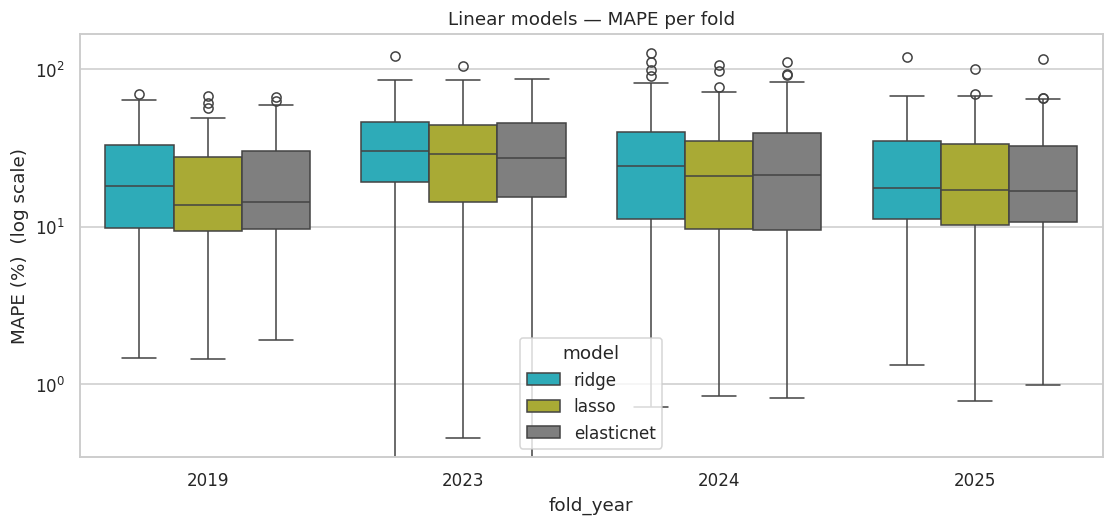

In [6]:
# ── Side-by-side MAPE distributions ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=combined,
            x="fold_year", y="mape", hue="model",
            ax=ax, palette={"ridge":"#17becf","lasso":"#bcbd22","elasticnet":"#7f7f7f"})
ax.set_yscale("log")
ax.set_title("Linear models — MAPE per fold")
ax.set_ylabel("MAPE (%)  (log scale)")
plt.savefig(FIG_DIR / "60_linear_perfold.png")
plt.show()


## 6.5  Coefficient inspection (Ridge on the demo port)

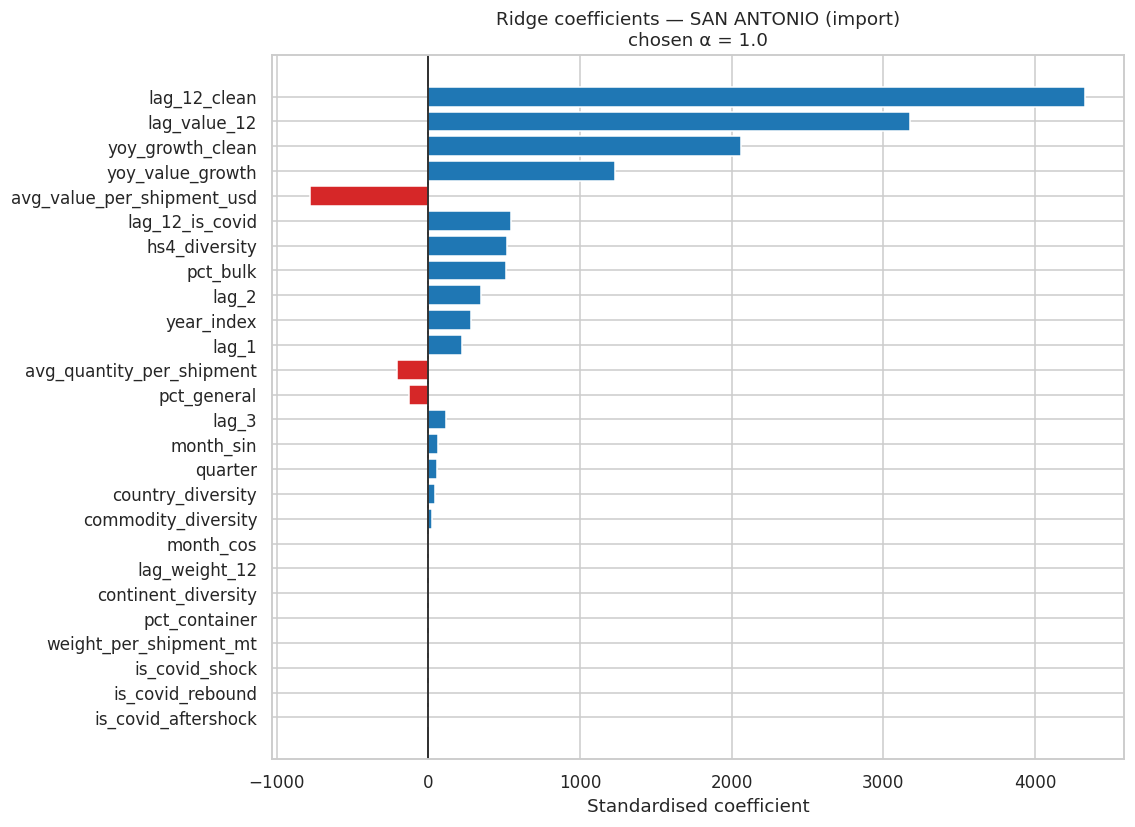

,feature,coefficient
3,lag_12_clean,4331.633535
4,lag_value_12,3173.705360
6,yoy_growth_clean,2061.096603
7,yoy_value_growth,1232.831758
19,avg_value_per_shipment_usd,-776.947725
25,lag_12_is_covid,548.044951
13,hs4_diversity,520.428007
17,pct_bulk,513.864409
1,lag_2,350.055442
11,year_index,282.224046


In [7]:
DEMO_PORT, DEMO_DIR = "SAN ANTONIO", "import"
df_port = U.get_port_panel(df_panel, DEMO_PORT, DEMO_DIR)
df_tr_full = df_port[(df_port["year"] < 2025) & (~df_port["year"].isin(U.COVID_YEARS))]
df_vl_full = df_port[df_port["year"] == 2025]
sel = U.select_features(df_tr_full)

Xtr = df_tr_full[sel].fillna(0).astype(float).values
ytr = df_tr_full[U.TARGET].astype(float).values
Xv  = df_vl_full[sel].fillna(0).astype(float).values
yv  = df_vl_full[U.TARGET].astype(float).values

pipe = Pipeline([("scale", StandardScaler()),
                  ("model", RidgeCV(alphas=[0.01,0.1,1,10,100]))])
pipe.fit(Xtr, ytr)
coefs = pipe.named_steps["model"].coef_
alpha = pipe.named_steps["model"].alpha_

coef_df = pd.DataFrame({"feature": sel, "coefficient": coefs}) \
            .sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, 0.32*len(coef_df))))
colors = ["#1f77b4" if c >= 0 else "#d62728" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Standardised coefficient")
ax.set_title(f"Ridge coefficients — {DEMO_PORT} ({DEMO_DIR})\n"
             f"chosen α = {alpha}")
plt.savefig(FIG_DIR / "61_ridge_coefficients.png")
plt.show()
coef_df.head(10)


Ridge 2025 validation: {'mae': 1709.0204465865415, 'rmse': 1900.1112359004628, 'mape': 3.7338051898726845, 'r2': 0.6683484692113963, 'n': 12}


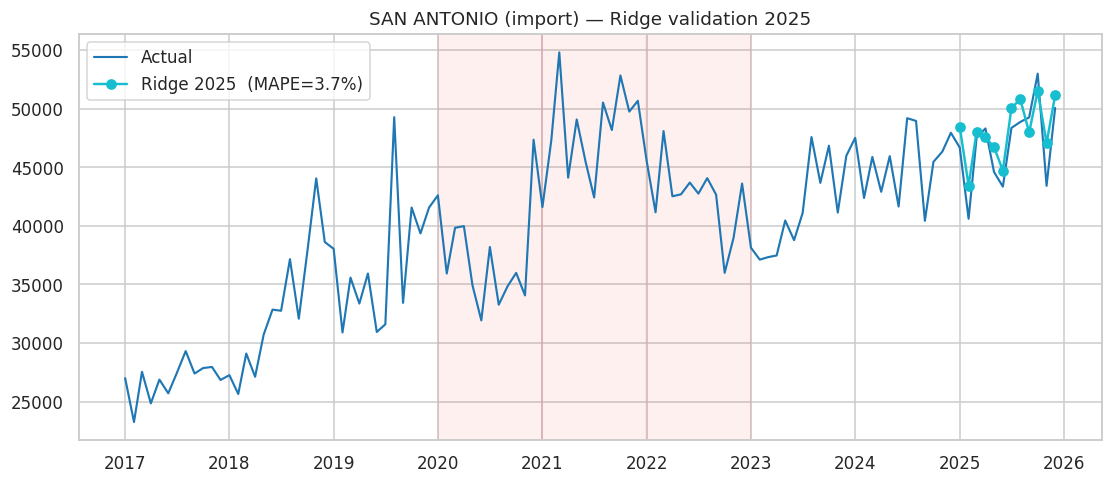

In [8]:
# ── Validation forecast plot ──────────────────────────────────────
val_pred = np.maximum(1.0, pipe.predict(Xv))
val_score = U.score(yv, val_pred)
print("Ridge 2025 validation:", val_score)

fig, ax = plt.subplots(figsize=(12, 4.8))
hist = df_port[df_port["year"].between(2017, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual")
vl_dates = pd.to_datetime(df_vl_full[["year","month"]].assign(day=1))
ax.plot(vl_dates, val_pred, "o-", color="#17becf", lw=1.6,
        label=f"Ridge 2025  (MAPE={val_score['mape']:.1f}%)")
for y in [2020,2021,2022]:
    ax.axvspan(pd.Timestamp(y,1,1), pd.Timestamp(y,12,31), color="red", alpha=0.06)
ax.set_title(f"{DEMO_PORT} ({DEMO_DIR}) — Ridge validation 2025")
ax.legend()
plt.savefig(FIG_DIR / "62_ridge_demo_2025.png")
plt.show()


## 6.6  How sparse is Lasso?

Lasso is the only one of the three that **drives coefficients to zero**.
Counting non-zero coefficients is the cleanest "feature selection"
metric we have.

In [9]:
pipe_l = Pipeline([("scale", StandardScaler()),
                    ("model", LassoCV(alphas=[0.001,0.01,0.1,1,10], max_iter=20000))])
pipe_l.fit(Xtr, ytr)
lasso_coefs = pipe_l.named_steps["model"].coef_
n_nonzero = int((np.abs(lasso_coefs) > 1e-6).sum())
print(f"Lasso α      : {pipe_l.named_steps['model'].alpha_}")
print(f"Non-zero β   : {n_nonzero}/{len(sel)}")

surviving = pd.DataFrame({"feature": sel, "coef": lasso_coefs})
surviving = surviving[np.abs(surviving["coef"]) > 1e-6].sort_values("coef", key=abs, ascending=False)
print("\nFeatures that survived Lasso shrinkage:")
print(surviving.to_string(index=False))


Lasso α      : 0.001
Non-zero β   : 19/26

Features that survived Lasso shrinkage:
                   feature        coef
              lag_12_clean 4684.087117
              lag_value_12 3515.105463
          yoy_growth_clean 2222.024691
          yoy_value_growth 1332.861717
avg_value_per_shipment_usd -845.866853
           lag_12_is_covid  570.355884
                  pct_bulk  423.523900
             hs4_diversity  262.921398
                     lag_2  216.714012
               pct_general -183.881116
                     lag_1  183.647739
 avg_quantity_per_shipment -173.718124
                year_index  117.406401
                 month_sin  105.171374
                   quarter   52.355131
       commodity_diversity   27.542065
                     lag_3  -25.734057
         country_diversity  -16.247877
                 month_cos    8.618923


## 6.7  2026 forecast (Ridge)

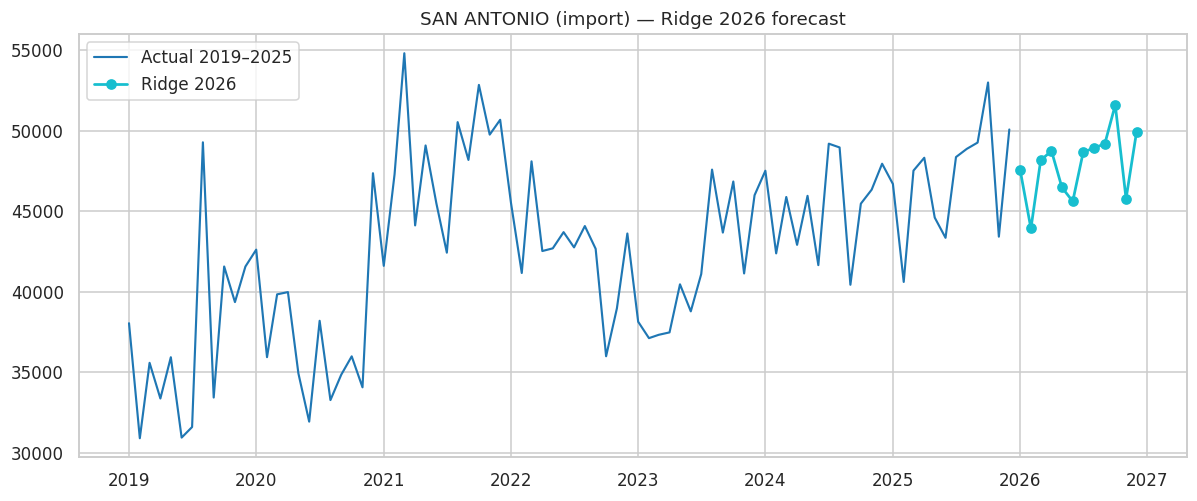

,year,month,pred_shipment_count
0,2026,1,47565.696030
1,2026,2,43923.280200
2,2026,3,48154.713292
3,2026,4,48740.717541
4,2026,5,46470.932102
5,2026,6,45606.147623
6,2026,7,48657.757809
7,2026,8,48925.418869
8,2026,9,49177.268821
9,2026,10,51595.416806


In [10]:
def ridge_fit_only(df_train, features):
    df_tr = df_train[(df_train["year"] < 2026) & (~df_train["year"].isin(U.COVID_YEARS))]
    Xtr = df_tr[features].fillna(0).astype(float).values
    ytr = df_tr[U.TARGET].astype(float).values
    p = Pipeline([("scale", StandardScaler()),
                   ("model", RidgeCV(alphas=[0.01,0.1,1,10,100]))])
    p.fit(Xtr, ytr); return p

def ridge_predict_one(model, df_row, features):
    return float(model.predict(df_row[features].fillna(0).astype(float).values)[0])

fc = U.forecast_2026(df_port, ridge_fit_only, ridge_predict_one)
fc["date"] = pd.to_datetime(fc[["year","month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(13, 5))
hist = df_port[df_port["year"].between(2019, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual 2019–2025")
ax.plot(fc["date"], fc["pred_shipment_count"], "o-", color="#17becf",
        lw=1.8, label="Ridge 2026")
ax.set_title(f"{DEMO_PORT} ({DEMO_DIR}) — Ridge 2026 forecast")
ax.legend()
plt.savefig(FIG_DIR / "63_ridge_2026.png")
plt.show()
fc[["year","month","pred_shipment_count"]]


## 6.8  2026 forecast — top-8 ports by volume (Ridge)

Forecasted 8 port-direction pairs in 1.3s


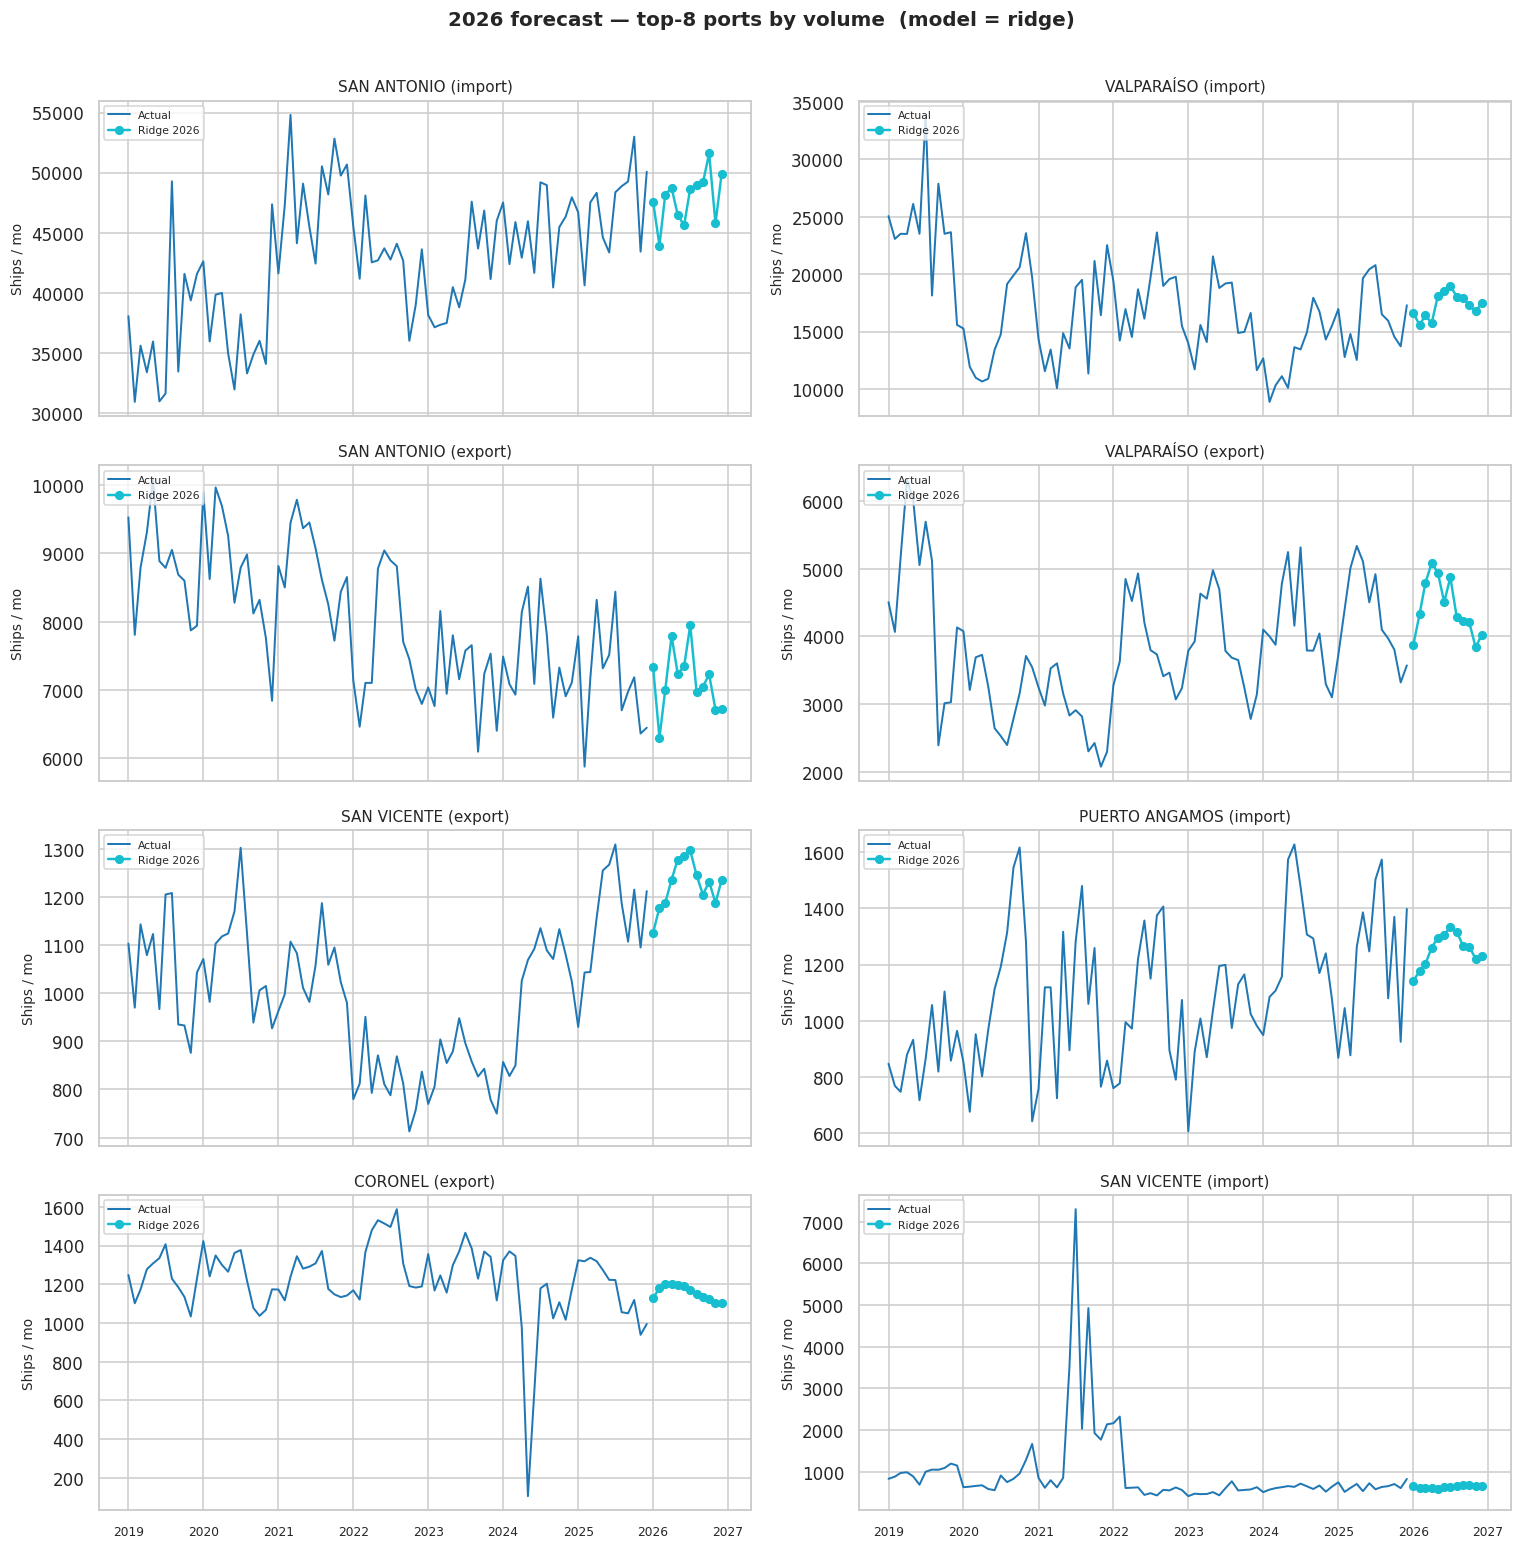

In [11]:
top8_volume = (df_panel.groupby(["port","direction"])[U.TARGET]
                       .mean().sort_values(ascending=False).head(8)
                       .reset_index())
top8_keys = list(zip(top8_volume["port"], top8_volume["direction"]))

import time as _time
_t0 = _time.time()
all_fc = []
for port, direction in top8_keys:
    _dp = U.get_port_panel(df_panel, port, direction)
    _fc = U.forecast_2026(_dp, ridge_fit_only, ridge_predict_one)
    if len(_fc):
        _fc["port"] = port; _fc["direction"] = direction
        all_fc.append(_fc)
fc_top8 = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
print(f"Forecasted {len(top8_keys)} port-direction pairs in {_time.time()-_t0:.1f}s")

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for ax, (port, direction) in zip(axes.flatten(), top8_keys):
    _dp = U.get_port_panel(df_panel, port, direction)
    hist = _dp[_dp["year"].between(2019, 2025)]
    hist_d = pd.to_datetime(hist[["year","month"]].assign(day=1))
    ax.plot(hist_d, hist[U.TARGET], color="#1f77b4", lw=1.3, label="Actual")

    sub = fc_top8[(fc_top8["port"] == port) & (fc_top8["direction"] == direction)]
    if len(sub):
        d2 = pd.to_datetime(sub[["year","month"]].assign(day=1))
        ax.plot(d2, sub["pred_shipment_count"], "o-",
                color="#17becf", lw=1.6, markersize=5, label="Ridge 2026")
    ax.set_title(f"{port} ({direction})", fontsize=10)
    ax.set_ylabel("Ships / mo", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(fontsize=7, loc="upper left")
plt.suptitle("2026 forecast — top-8 ports by volume  (model = ridge)",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / "64_ridge_top8_2026.png")
plt.show()


## 6.9  Take-aways

1. **Sign of coefficients** confirms intuitions: lag features and rolling
   means are positive, COVID flags are negative, growth rate has the
   expected positive sign.
2. **Lasso sparsity** mirrors the gain importance from LightGBM — the
   features Lasso keeps are essentially the same ones that the trees
   split on most often. This is independent confirmation that the
   feature engineering layer is well-designed.
3. The MAPE gap between Ridge and LightGBM (visible in notebook 08) is
   the **value of non-linearity and feature interactions**. If the gap
   is small, a linear model is the right production choice for any port
   where interpretability matters.
